# Phân loại Iris với Machine Learning và PyTorch

Trong bài thực hành này, chúng ta xây dựng **một quy trình Machine Learning hoàn chỉnh** trên bộ dữ liệu Iris:

**Dữ liệu → Khám phá dữ liệu → Tiền xử lý → Tìm đặc trưng tốt → Machine Learning → PyTorch → Đánh giá và so sánh**

### Mục tiêu
Sau bài này, sinh viên có thể:

- Đọc và khảo sát một bộ dữ liệu phân loại.
- Kiểm tra missing values, duplicate và phân bố lớp.
- Trực quan hóa dữ liệu bằng histogram, boxplot, scatter plot và pairplot.
- Chuẩn hóa dữ liệu đúng cách, tránh **data leakage**.
- Đánh giá chất lượng đặc trưng bằng:
  - ANOVA F-test
  - Mutual Information
  - Thử nghiệm các tổ hợp đặc trưng bằng Cross-Validation
- Xây dựng mô hình Machine Learning với Scikit-Learn.
- Xây dựng mạng Neural Network với PyTorch.
- So sánh mô hình dùng **toàn bộ đặc trưng** và **các đặc trưng tốt nhất**.
- Đánh giá bằng Accuracy, Precision, Recall, F1-score và Confusion Matrix.

> Bộ dữ liệu Iris gồm 150 mẫu, 4 đặc trưng và 3 lớp: **setosa, versicolor, virginica**.

## 1. Cài đặt và khai báo thư viện

Nếu môi trường chưa có các thư viện cần thiết, có thể cài bằng:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn torch
```

In [1]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Thiết lập seed để kết quả có thể tái lập
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("NumPy version :", np.__version__)
print("PyTorch version:", torch.__version__)
print("Thiết bị PyTorch:", "cuda" if torch.cuda.is_available() else "cpu")

NumPy version : 2.4.4
PyTorch version: 2.14.1+cu130
Thiết bị PyTorch: cpu


## 2. Chuẩn bị dữ liệu Iris

Bộ dữ liệu Iris có 4 đặc trưng:

1. `sepal length (cm)` – chiều dài đài hoa
2. `sepal width (cm)` – chiều rộng đài hoa
3. `petal length (cm)` – chiều dài cánh hoa
4. `petal width (cm)` – chiều rộng cánh hoa

Nhãn cần dự đoán gồm 3 lớp:

- `setosa`
- `versicolor`
- `virginica`

> **Nguồn dữ liệu:** file `iris.csv` của môn học (150 dòng, **không có dòng tiêu đề**, cột cuối là tên loài dạng `Iris-setosa`, ...). Ta đặt tên cột theo chuẩn của Scikit-Learn để các bước sau dùng chung.


In [2]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

IRIS_PATH = "iris.csv"   # file trong iris_v1/data/

feature_names = np.array([
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
])

raw = pd.read_csv(
    IRIS_PATH,
    header=None,
    names=list(feature_names) + ["class"]
)

# Chuyển nhãn dạng chuỗi -> số (Label Encoding)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(raw["class"])

target_names = np.array([c.replace("Iris-", "") for c in label_encoder.classes_])
X = raw[list(feature_names)].values.astype(float)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Features :", feature_names)
print("Classes  :", target_names)
print("Mã hóa   :", dict(zip(target_names, range(len(target_names)))))

Shape X: (150, 4)
Shape y: (150,)
Features : ['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']
Classes  : ['setosa' 'versicolor' 'virginica']
Mã hóa   : {np.str_('setosa'): 0, np.str_('versicolor'): 1, np.str_('virginica'): 2}


In [3]:
# Chuyển sang DataFrame để dễ quan sát
df = pd.DataFrame(X, columns=feature_names)
df["class_id"] = y
df["species"] = target_names[y]

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


### Chuyển đổi dữ liệu danh mục sang số và One-Hot

Nhãn `species` là dữ liệu **danh mục**. Có hai cách biểu diễn:

| Cách | Ví dụ | Dùng khi |
|---|---|---|
| Label Encoding | setosa → 0, versicolor → 1, virginica → 2 | `CrossEntropyLoss` của PyTorch, `LogisticRegression` của Scikit-Learn |
| One-Hot | setosa → [1,0,0] | Một số thuật toán/loss cần nhãn dạng vector |

Trong bài này nhãn đầu ra dùng **Label Encoding**. One-Hot chỉ minh họa bên dưới.

In [4]:
onehot_demo = pd.get_dummies(df["species"], dtype=int)

pd.concat(
    [df[["species", "class_id"]], onehot_demo],
    axis=1
).drop_duplicates("species")

,species,class_id,setosa,versicolor,virginica
0,setosa,0,1,0,0
50,versicolor,1,0,1,0
100,virginica,2,0,0,1


## 3. Khám phá và kiểm tra dữ liệu

Trước khi xây dựng mô hình, cần trả lời một số câu hỏi:

- Dữ liệu có bao nhiêu mẫu?
- Các thuộc tính có kiểu dữ liệu gì?
- Có dữ liệu thiếu không?
- Có bản ghi trùng không?
- Các lớp có cân bằng không?
- Phân bố của từng đặc trưng như thế nào?

In [5]:
print("Kích thước dữ liệu:", df.shape)
print("\nThông tin dữ liệu:")
df.info()

Kích thước dữ liệu: (150, 6)

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class_id           150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
# Thống kê mô tả
df[feature_names].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Kiểm tra missing values
print("Số giá trị NULL ở từng cột:")
print(df.isnull().sum())

Số giá trị NULL ở từng cột:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
class_id             0
species              0
dtype: int64


In [8]:
# Kiểm tra dữ liệu trùng
n_duplicates = df.duplicated().sum()
print("Số dòng bị trùng:", n_duplicates)

# Lưu ý:
# Không nên tự động xóa duplicate trong mọi bài toán.
# Hai đối tượng thực tế vẫn có thể có cùng giá trị đo.

Số dòng bị trùng: 3


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


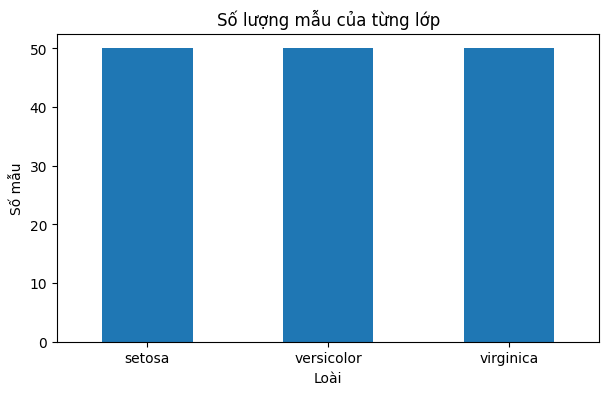

In [9]:
# Kiểm tra phân bố các lớp
class_counts = df["species"].value_counts().sort_index()

print(class_counts)

ax = class_counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Số lượng mẫu của từng lớp")
ax.set_xlabel("Loài")
ax.set_ylabel("Số mẫu")
plt.xticks(rotation=0)
plt.show()

### 3.1 Làm sạch dữ liệu: xóa dữ liệu trùng nhau

Theo quy trình trong tài liệu *Rút trích dữ liệu và tiền xử lý*, bước làm sạch gồm:

1. Giữ lại các cột cần thiết (4 cột đầu vào + nhãn) 
2. **Xóa dòng trùng nhau**
3. Xử lý giá trị thiếu (Iris **không có** giá trị thiếu)

Các dòng trùng hoàn toàn có thể rơi vào cả tập train lẫn test, khiến mô hình "gặp lại" đúng mẫu đã học và làm điểm test cao hơn thực tế. Vì vậy ta xóa chúng và dùng bảng dữ liệu sạch cho các bước sau.

In [10]:
dup_mask = df.duplicated(subset=list(feature_names) + ["class_id"], keep="first")

print("Các dòng bị trùng (so với dòng xuất hiện trước đó):")
display(df[dup_mask])

df_clean = (
    df.drop_duplicates(subset=list(feature_names) + ["class_id"], keep="first")
      .reset_index(drop=True)
)

print(f"\nTrước: {len(df)} dòng  ->  Sau: {len(df_clean)} dòng")
print("\nPhân bố lớp sau khi làm sạch:")
print(df_clean["species"].value_counts().sort_index())

# Từ đây dùng bảng dữ liệu sạch
df = df_clean
X = df[list(feature_names)].values.astype(float)
y = df["class_id"].values

Các dòng bị trùng (so với dòng xuất hiện trước đó):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class_id,species
34,4.9,3.1,1.5,0.1,0,setosa
37,4.9,3.1,1.5,0.1,0,setosa
142,5.8,2.7,5.1,1.9,2,virginica



Trước: 150 dòng  ->  Sau: 147 dòng

Phân bố lớp sau khi làm sạch:
species
setosa        48
versicolor    50
virginica     49
Name: count, dtype: int64


## 4. Trực quan hóa dữ liệu

Mục tiêu của bước này là quan sát xem đặc trưng nào giúp các lớp **tách biệt nhau tốt**.

Ta sử dụng:

- Histogram
- Boxplot
- Pairplot
- Scatter plot

Đặc biệt, hãy chú ý hai đặc trưng:

- `petal length (cm)`
- `petal width (cm)`

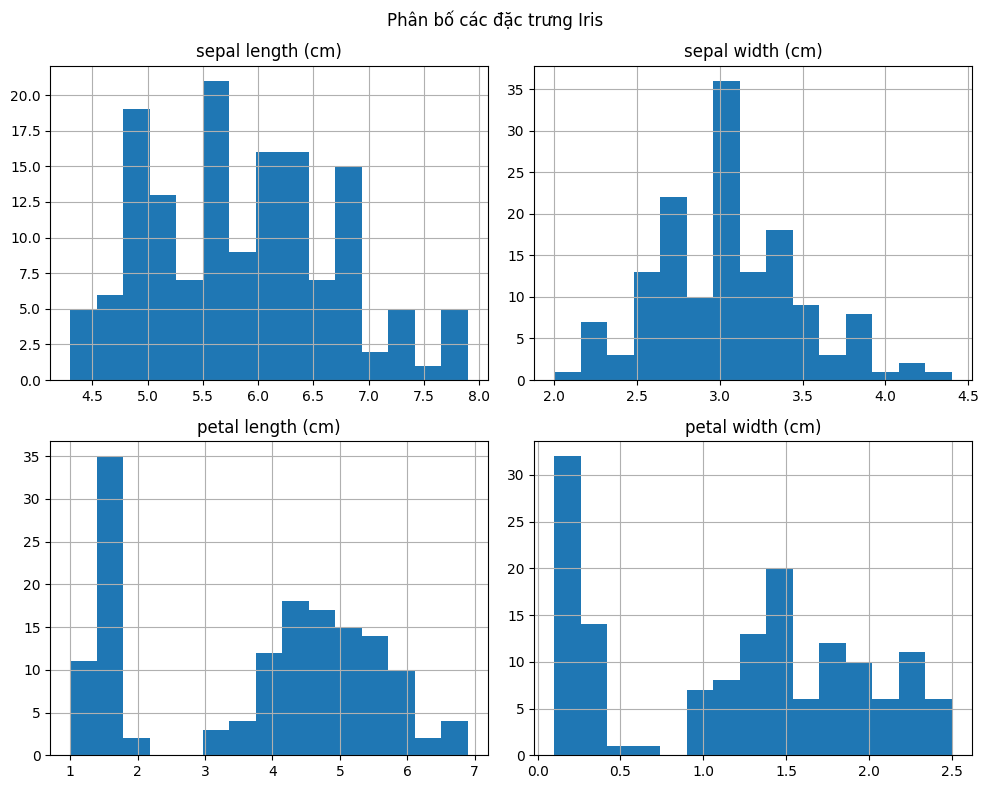

In [11]:
# Histogram của 4 đặc trưng
df[feature_names].hist(figsize=(10, 8), bins=15)
plt.suptitle("Phân bố các đặc trưng Iris")
plt.tight_layout()
plt.show()

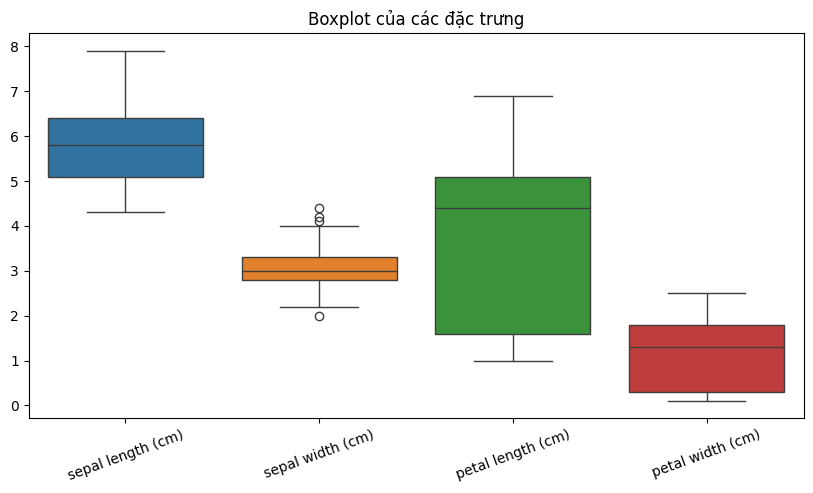

In [12]:
# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[feature_names])
plt.title("Boxplot của các đặc trưng")
plt.xticks(rotation=20)
plt.show()

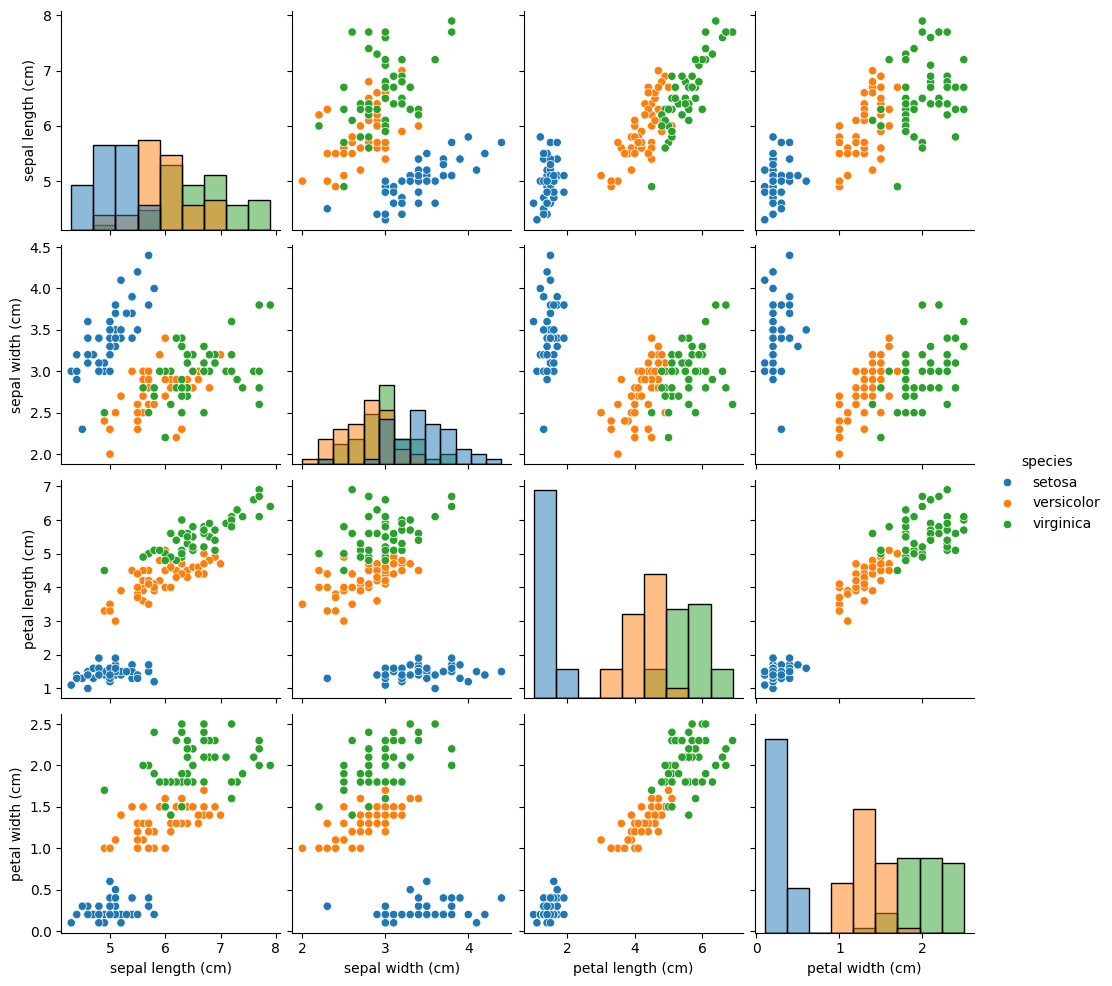

In [13]:
# Pairplot giúp quan sát khả năng phân tách các lớp
sns.pairplot(
    df,
    vars=feature_names.tolist(),
    hue="species",
    diag_kind="hist"
)
plt.show()

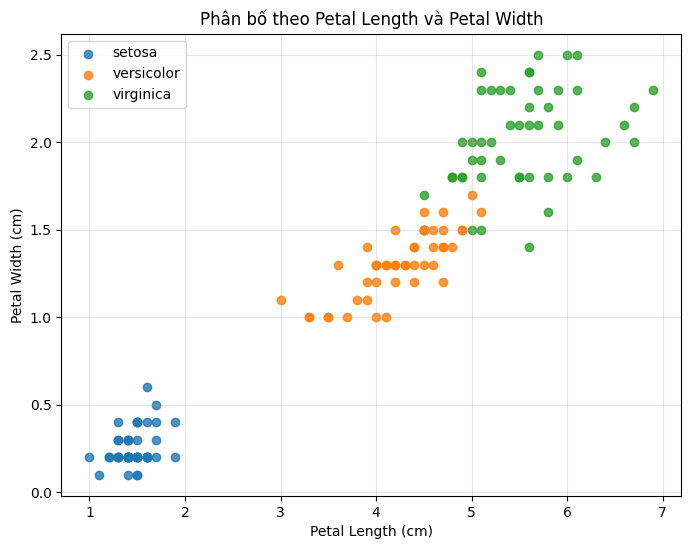

In [14]:
# Quan sát trực tiếp Petal Length và Petal Width
plt.figure(figsize=(8, 6))

for species in target_names:
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species,
        alpha=0.8
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Phân bố theo Petal Length và Petal Width")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

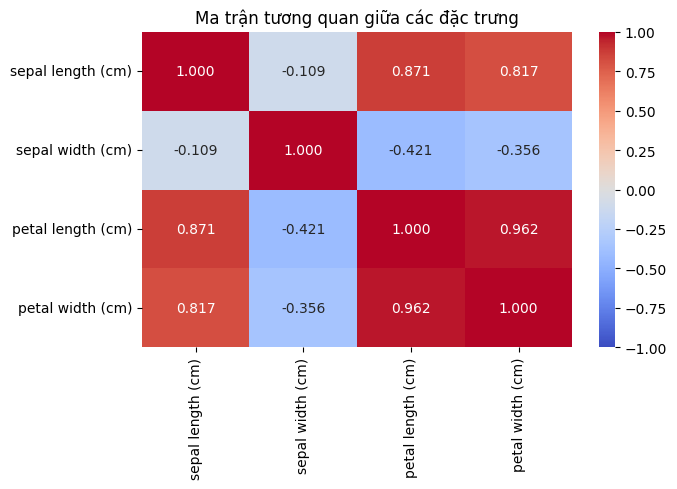

Tương quan với class_id:
petal width (cm)     0.956
petal length (cm)    0.948
sepal length (cm)    0.783
sepal width (cm)    -0.418
dtype: float64


In [15]:
# Ma trận tương quan giữa các đặc trưng (Pearson)
corr = df[list(feature_names)].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.tight_layout()
plt.show()

# Tương quan của từng đặc trưng với nhãn lớp (đã mã hóa số)
print("Tương quan với class_id:")
print(df[list(feature_names)].corrwith(df["class_id"]).sort_values(ascending=False).round(3))

## 5. Chia dữ liệu Train/Test trước khi chọn đặc trưng

Đây là bước rất quan trọng.

Ta giữ riêng tập **test** và không sử dụng nó để:

- fit scaler,
- chọn đặc trưng,
- điều chỉnh mô hình.

Nhờ đó, kết quả trên tập test phản ánh tốt hơn khả năng tổng quát hóa.

Sử dụng `stratify=y` để giữ tỷ lệ 3 lớp tương tự nhau ở train và test.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nPhân bố lớp train:", np.bincount(y_train))
print("Phân bố lớp test :", np.bincount(y_test))

Train: (117, 4) (117,)
Test : (30, 4) (30,)

Phân bố lớp train: [38 40 39]
Phân bố lớp test : [10 10 10]


## 6. Tìm đặc trưng tốt

Ta sử dụng nhiều cách khác nhau để tránh kết luận chỉ dựa vào quan sát bằng mắt.

### 6.1 ANOVA F-test

ANOVA F-test kiểm tra mức độ khác biệt của giá trị một đặc trưng giữa các lớp.

- **F-score lớn** → đặc trưng có khả năng phân biệt lớp tốt hơn.
- **p-value nhỏ** → sự khác biệt có ý nghĩa thống kê hơn.

Việc xếp hạng dưới đây chỉ sử dụng **tập train**.

In [17]:
f_scores, p_values = f_classif(X_train, y_train)

anova_df = pd.DataFrame({
    "Feature": feature_names,
    "F-score": f_scores,
    "p-value": p_values
}).sort_values("F-score", ascending=False)

anova_df

,Feature,F-score,p-value
2,petal length (cm),877.284450,5.855405e-70
3,petal width (cm),750.654154,2.360572e-66
0,sepal length (cm),98.429613,1.470422e-25
1,sepal width (cm),32.569652,6.481809e-12


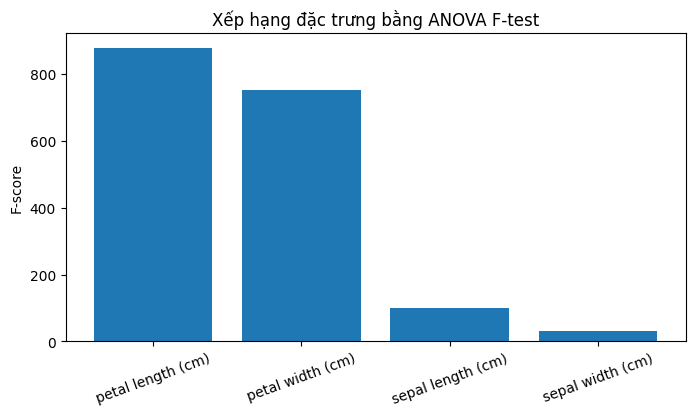

In [18]:
plt.figure(figsize=(8, 4))
plt.bar(anova_df["Feature"], anova_df["F-score"])
plt.title("Xếp hạng đặc trưng bằng ANOVA F-test")
plt.ylabel("F-score")
plt.xticks(rotation=20)
plt.show()

### 6.2 Mutual Information

Mutual Information đo lượng thông tin mà một đặc trưng cung cấp về nhãn lớp.

Ưu điểm:

- Không yêu cầu quan hệ tuyến tính.
- Có thể phát hiện các mối quan hệ phức tạp hơn correlation.

In [19]:
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=SEED
)

mi_df = pd.DataFrame({
    "Feature": feature_names,
    "Mutual Information": mi_scores
}).sort_values("Mutual Information", ascending=False)

mi_df

,Feature,Mutual Information
3,petal width (cm),0.989742
2,petal length (cm),0.987709
0,sepal length (cm),0.583009
1,sepal width (cm),0.255705


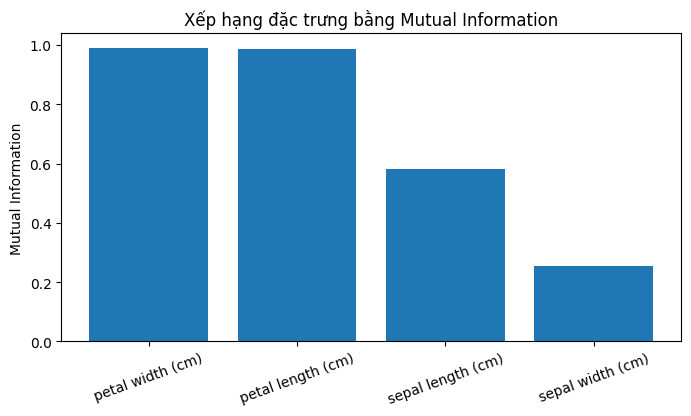

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(mi_df["Feature"], mi_df["Mutual Information"])
plt.title("Xếp hạng đặc trưng bằng Mutual Information")
plt.ylabel("Mutual Information")
plt.xticks(rotation=20)
plt.show()

### 6.3 Thử tất cả các tổ hợp đặc trưng bằng Cross-Validation

Iris chỉ có 4 đặc trưng nên ta có thể thử toàn bộ:

- 4 tổ hợp dùng 1 đặc trưng
- 6 tổ hợp dùng 2 đặc trưng
- 4 tổ hợp dùng 3 đặc trưng
- 1 tổ hợp dùng 4 đặc trưng

Tổng cộng chỉ có **15 tổ hợp**.

Mỗi tổ hợp được đánh giá bằng **5-fold Stratified Cross-Validation** trên tập train.

Pipeline gồm:

`StandardScaler → LogisticRegression`

Cách này giúp trả lời trực tiếp:

> Tập đặc trưng nào thực sự tạo ra mô hình phân loại tốt?

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

feature_results = []

for k in range(1, X_train.shape[1] + 1):

    for idx in combinations(range(X_train.shape[1]), k):

        X_sub = X_train[:, idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ])

        scores = cross_val_score(
            pipeline,
            X_sub,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        feature_results.append({
            "N_features": k,
            "Feature_indices": idx,
            "Features": ", ".join(feature_names[list(idx)]),
            "CV_mean_accuracy": scores.mean(),
            "CV_std": scores.std()
        })

feature_results_df = pd.DataFrame(feature_results)
feature_results_df = feature_results_df.sort_values(
    ["CV_mean_accuracy", "N_features"],
    ascending=[False, True]
).reset_index(drop=True)

feature_results_df

,N_features,Feature_indices,Features,CV_mean_accuracy,CV_std
0,1,"(3,)",petal width (cm),0.965942,0.017048
1,2,"(0, 3)","sepal length (cm), petal width (cm)",0.965580,0.032447
2,3,"(0, 2, 3)","sepal length (cm), petal length (cm), petal wi...",0.965580,0.032447
3,1,"(2,)",petal length (cm),0.957609,0.038097
4,2,"(2, 3)","petal length (cm), petal width (cm)",0.957246,0.038097
5,3,"(0, 1, 3)","sepal length (cm), sepal width (cm), petal wid...",0.957246,0.027512
6,3,"(1, 2, 3)","sepal width (cm), petal length (cm), petal wid...",0.957246,0.038097
7,4,"(0, 1, 2, 3)","sepal length (cm), sepal width (cm), petal len...",0.957246,0.038097
8,2,"(1, 3)","sepal width (cm), petal width (cm)",0.949275,0.030999
9,2,"(1, 2)","sepal width (cm), petal length (cm)",0.931884,0.034096


In [22]:
# 10 tổ hợp tốt nhất
feature_results_df.head(10)

,N_features,Feature_indices,Features,CV_mean_accuracy,CV_std
0,1,"(3,)",petal width (cm),0.965942,0.017048
1,2,"(0, 3)","sepal length (cm), petal width (cm)",0.965580,0.032447
2,3,"(0, 2, 3)","sepal length (cm), petal length (cm), petal wi...",0.965580,0.032447
3,1,"(2,)",petal length (cm),0.957609,0.038097
4,2,"(2, 3)","petal length (cm), petal width (cm)",0.957246,0.038097
5,3,"(0, 1, 3)","sepal length (cm), sepal width (cm), petal wid...",0.957246,0.027512
6,3,"(1, 2, 3)","sepal width (cm), petal length (cm), petal wid...",0.957246,0.038097
7,4,"(0, 1, 2, 3)","sepal length (cm), sepal width (cm), petal len...",0.957246,0.038097
8,2,"(1, 3)","sepal width (cm), petal width (cm)",0.949275,0.030999
9,2,"(1, 2)","sepal width (cm), petal length (cm)",0.931884,0.034096


In [23]:
# Tổ hợp tốt nhất theo Cross-Validation
best_row = feature_results_df.iloc[0]

best_feature_indices = list(best_row["Feature_indices"])
best_feature_names = feature_names[best_feature_indices]

print("Các đặc trưng tốt nhất theo CV:")
for name in best_feature_names:
    print("-", name)

print(f"\nCV Accuracy trung bình: {best_row['CV_mean_accuracy']:.4f}")
print(f"CV Std                : {best_row['CV_std']:.4f}")

Các đặc trưng tốt nhất theo CV:
- petal width (cm)

CV Accuracy trung bình: 0.9659
CV Std                : 0.0170


> **Gợi ý quan sát:** Với Iris, `petal length` và `petal width` thường nằm trong nhóm đặc trưng mạnh nhất. Tuy nhiên, ta để kết quả Cross-Validation quyết định thay vì gán trước kết luận.

Trong phần tiếp theo, ta còn tạo thêm một bộ **Petal Features** cố định gồm `petal length` và `petal width` để sinh viên dễ trực quan hóa và so sánh.

In [24]:
# Bộ 2 đặc trưng petal để minh họa
petal_feature_indices = [2, 3]

print("Petal features:")
for idx in petal_feature_indices:
    print("-", feature_names[idx])

Petal features:
- petal length (cm)
- petal width (cm)


## 7. Tiền xử lý dữ liệu: Standardization

Một số mô hình như:

- Logistic Regression
- KNN
- SVM
- Neural Network

thường hoạt động tốt hơn khi các đặc trưng được chuẩn hóa.

StandardScaler thực hiện:

\[
z = \frac{x - \mu}{\sigma}
\]

### Nguyên tắc quan trọng

```text
fit scaler      → chỉ trên TRAIN
transform       → TRAIN và TEST
```

Không được `fit` scaler trên toàn bộ dữ liệu trước khi chia train/test vì sẽ gây **data leakage**.

In [25]:
scaler_all = StandardScaler()

X_train_scaled = scaler_all.fit_transform(X_train)
X_test_scaled = scaler_all.transform(X_test)

print("Mean train sau chuẩn hóa:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nStd train sau chuẩn hóa:")
print(np.round(X_train_scaled.std(axis=0), 4))

Mean train sau chuẩn hóa:
[-0.  0.  0. -0.]

Std train sau chuẩn hóa:
[1. 1. 1. 1.]


### 7.1 Min-Max và Standard: dùng cái nào?

Có hai cách chuẩn hóa phổ biến:

$$
\text{Min-Max: } z = \frac{x - \min(x)}{\max(x) - \min(x)} \qquad
\text{Standard: } z = \frac{x - \mu}{\sigma}
$$

Min-Max đưa dữ liệu về $[0,1]$; Standard đưa về trung bình 0, độ lệch chuẩn 1. Cả hai đều **chỉ fit trên train**. Ta so sánh bằng Cross-Validation trên tập train (không dùng test).

In [26]:
minmax = MinMaxScaler().fit(X_train)
X_train_mm = minmax.transform(X_train)

print("Min-Max (train): min =", X_train_mm.min(axis=0).round(2), " max =", X_train_mm.max(axis=0).round(2))

scaling_rows = []
for scaler_name, scaler_obj in [
    ("Không chuẩn hóa", None),
    ("Min-Max", MinMaxScaler()),
    ("Standard", StandardScaler()),
]:
    for model_name, clf in [
        ("Logistic Regression", LogisticRegression(max_iter=1000)),
        ("KNN", KNeighborsClassifier(n_neighbors=5)),
        ("SVM-RBF", SVC(kernel="rbf")),
    ]:
        steps = ([("scaler", scaler_obj)] if scaler_obj is not None else []) + [("model", clf)]
        s = cross_val_score(Pipeline(steps), X_train, y_train, cv=cv, scoring="accuracy")
        scaling_rows.append({"Chuẩn hóa": scaler_name, "Model": model_name, "CV Accuracy": s.mean()})

(pd.DataFrame(scaling_rows)
   .pivot(index="Model", columns="Chuẩn hóa", values="CV Accuracy")
   .round(4))

Min-Max (train): min = [0. 0. 0. 0.]  max = [1. 1. 1. 1.]


Chuẩn hóa,Không chuẩn hóa,Min-Max,Standard
Model,,,
KNN,0.9743,0.9572,0.9482
Logistic Regression,0.9656,0.9315,0.9572
SVM-RBF,0.9659,0.9746,0.9659


## 8. Machine Learning với Scikit-Learn

Ta thử 3 mô hình phổ biến:

1. Logistic Regression
2. K-Nearest Neighbors
3. Support Vector Machine

Để đánh giá ổn định hơn, đầu tiên ta dùng **5-fold Cross-Validation** trên tập train.

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM-RBF": SVC(kernel="rbf")
}

ml_cv_results = []

for name, clf in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clf)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    ml_cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

ml_cv_df = pd.DataFrame(ml_cv_results).sort_values(
    "CV Mean Accuracy",
    ascending=False
)

ml_cv_df

,Model,CV Mean Accuracy,CV Std
2,SVM-RBF,0.965942,0.041728
0,Logistic Regression,0.957246,0.038097
1,KNN,0.948188,0.050771


## 9. Baseline: Logistic Regression với toàn bộ 4 đặc trưng

Ta dùng Logistic Regression làm baseline vì:

- đơn giản,
- dễ hiểu,
- phù hợp với bài toán phân loại đa lớp,
- giúp so sánh rõ với Neural Network ở phần sau.

In [28]:
lr_all = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_all.fit(X_train, y_train)

y_pred_lr_all = lr_all.predict(X_test)

acc_lr_all = accuracy_score(y_test, y_pred_lr_all)

print(f"Accuracy - Logistic Regression / All features: {acc_lr_all:.4f}")
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred_lr_all,
        target_names=target_names
    )
)

Accuracy - Logistic Regression / All features: 0.9333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



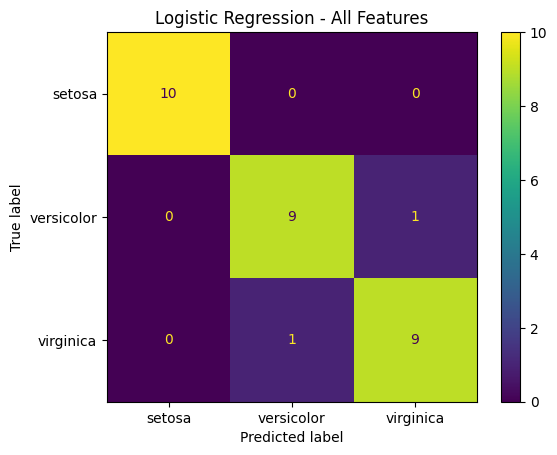

In [29]:
cm = confusion_matrix(y_test, y_pred_lr_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot()
plt.title("Logistic Regression - All Features")
plt.show()

## 10. Logistic Regression với các đặc trưng tốt nhất

Ta sử dụng tổ hợp đặc trưng tốt nhất được tìm từ **Cross-Validation trên tập train**.

Tập test vẫn hoàn toàn chưa được dùng để chọn feature.

In [30]:
X_train_best = X_train[:, best_feature_indices]
X_test_best = X_test[:, best_feature_indices]

lr_best = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_best.fit(X_train_best, y_train)

y_pred_lr_best = lr_best.predict(X_test_best)

acc_lr_best = accuracy_score(y_test, y_pred_lr_best)

print("Best features:", best_feature_names.tolist())
print(f"Accuracy - Logistic Regression / Best features: {acc_lr_best:.4f}")

Best features: ['petal width (cm)']
Accuracy - Logistic Regression / Best features: 0.9333


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



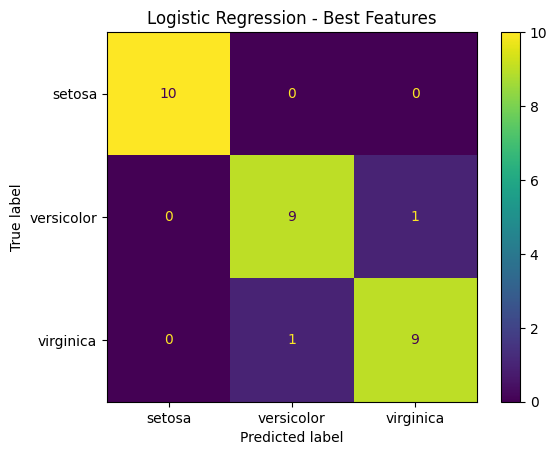

In [31]:
print(
    classification_report(
        y_test,
        y_pred_lr_best,
        target_names=target_names
    )
)

cm = confusion_matrix(y_test, y_pred_lr_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot()
plt.title("Logistic Regression - Best Features")
plt.show()

## 11. Thử riêng Petal Length + Petal Width

Hai đặc trưng `petal length` và `petal width` rất thuận lợi cho việc trực quan hóa trên mặt phẳng 2D.

Ta kiểm tra xem chỉ dùng hai biến này có thể đạt kết quả gần với mô hình 4 biến hay không.

In [32]:
X_train_petal = X_train[:, petal_feature_indices]
X_test_petal = X_test[:, petal_feature_indices]

lr_petal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_petal.fit(X_train_petal, y_train)

y_pred_lr_petal = lr_petal.predict(X_test_petal)

acc_lr_petal = accuracy_score(y_test, y_pred_lr_petal)

print(f"Accuracy - Logistic Regression / Petal features: {acc_lr_petal:.4f}")

Accuracy - Logistic Regression / Petal features: 0.9333


## 12. Chuẩn bị dữ liệu cho PyTorch

PyTorch sử dụng Tensor.

Đối với bài toán phân loại nhiều lớp:

- `X` dùng `torch.float32`
- `y` dùng `torch.long`

Ta sẽ huấn luyện hai Neural Network:

1. Neural Network với **4 đặc trưng**
2. Neural Network với **các đặc trưng tốt nhất**

In [33]:
# Dùng scaler đã fit trên TRAIN ở phần trước
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X train tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y train tensor:", y_train_tensor.shape, y_train_tensor.dtype)

X train tensor: torch.Size([117, 4]) torch.float32
y train tensor: torch.Size([117]) torch.int64


## 13. Xây dựng Neural Network bằng PyTorch

Mạng cho 4 đặc trưng:

```text
4 inputs
   ↓
Linear 4 → 16
   ↓
ReLU
   ↓
Linear 16 → 8
   ↓
ReLU
   ↓
Linear 8 → 3
   ↓
3 classes
```

Không đặt Softmax ở tầng cuối vì `nn.CrossEntropyLoss()` nhận trực tiếp **logits**.

In [34]:
class IrisNet(nn.Module):

    def __init__(self, n_inputs=4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.net(x)


model_all = IrisNet(n_inputs=X_train.shape[1])
print(model_all)

IrisNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


## 14. Hàm huấn luyện PyTorch

Ta viết một hàm dùng chung để có thể huấn luyện nhiều cấu hình mạng.

Các bước trong mỗi epoch:

1. Forward
2. Tính loss
3. `zero_grad()`
4. `backward()`
5. `optimizer.step()`

In [35]:
def train_pytorch_model(
    model,
    X_train_tensor,
    y_train_tensor,
    epochs=300,
    learning_rate=0.01,
    verbose_every=50
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "loss": [],
        "accuracy": []
    }

    start_time = time.time()

    for epoch in range(1, epochs + 1):

        model.train()

        optimizer.zero_grad()

        logits = model(X_train_tensor)

        loss = criterion(
            logits,
            y_train_tensor
        )

        loss.backward()

        optimizer.step()

        with torch.no_grad():
            pred = logits.argmax(dim=1)
            acc = (pred == y_train_tensor).float().mean().item()

        history["loss"].append(loss.item())
        history["accuracy"].append(acc)

        if epoch == 1 or epoch % verbose_every == 0:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Loss = {loss.item():.4f} | "
                f"Train Accuracy = {acc:.4f}"
            )

    training_time = time.time() - start_time

    print(f"Training time: {training_time:.4f} seconds")

    return history

## 15. Huấn luyện Neural Network với 4 đặc trưng

In [36]:
torch.manual_seed(SEED)

model_all = IrisNet(n_inputs=4)

history_all = train_pytorch_model(
    model=model_all,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    epochs=300,
    learning_rate=0.01,
    verbose_every=50
)

Epoch   1/300 | Loss = 1.0981 | Train Accuracy = 0.3248
Epoch  50/300 | Loss = 0.0890 | Train Accuracy = 0.9744
Epoch 100/300 | Loss = 0.0348 | Train Accuracy = 0.9829
Epoch 150/300 | Loss = 0.0291 | Train Accuracy = 0.9829


Epoch 200/300 | Loss = 0.0255 | Train Accuracy = 0.9829
Epoch 250/300 | Loss = 0.0237 | Train Accuracy = 0.9829
Epoch 300/300 | Loss = 0.0228 | Train Accuracy = 0.9829
Training time: 0.3753 seconds


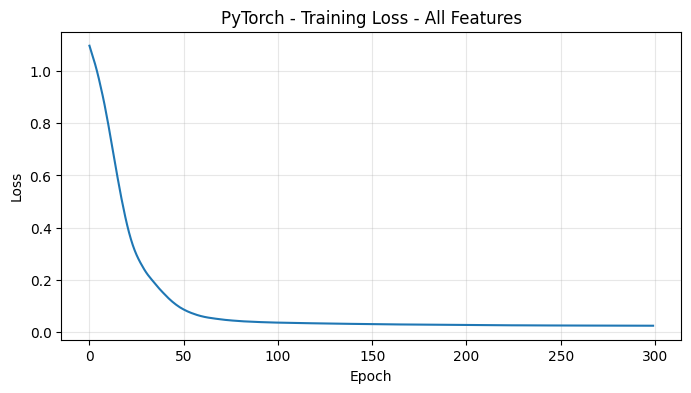

In [37]:
# Vẽ Loss
plt.figure(figsize=(8, 4))
plt.plot(history_all["loss"])
plt.title("PyTorch - Training Loss - All Features")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

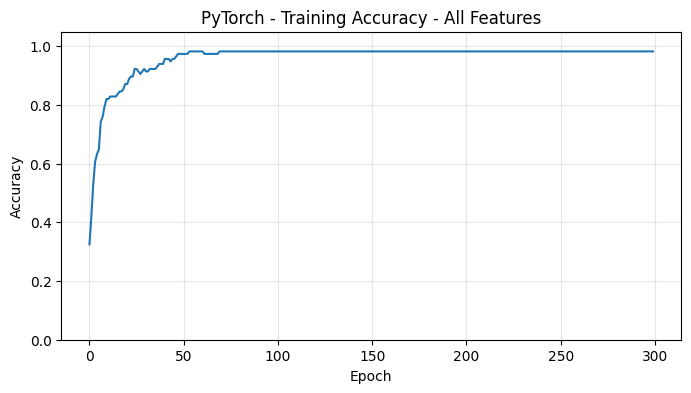

In [38]:
# Vẽ Accuracy
plt.figure(figsize=(8, 4))
plt.plot(history_all["accuracy"])
plt.title("PyTorch - Training Accuracy - All Features")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

## 16. Lượng giá Neural Network với 4 đặc trưng

In [39]:
model_all.eval()

with torch.no_grad():

    logits_test = model_all(X_test_tensor)

    y_pred_nn_all = logits_test.argmax(dim=1).cpu().numpy()

acc_nn_all = accuracy_score(y_test, y_pred_nn_all)

print(f"PyTorch Test Accuracy - All features: {acc_nn_all:.4f}")

print(
    classification_report(
        y_test,
        y_pred_nn_all,
        target_names=target_names
    )
)

PyTorch Test Accuracy - All features: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



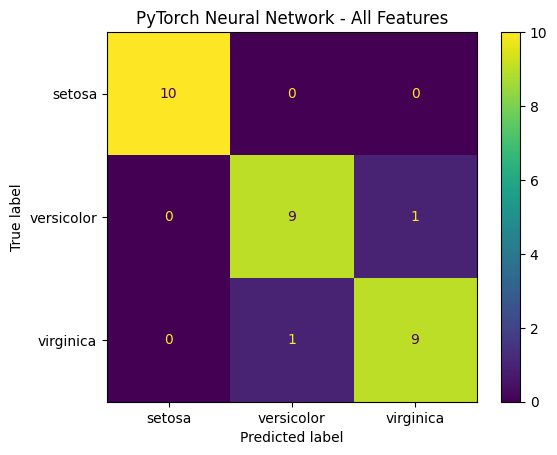

In [40]:
cm = confusion_matrix(y_test, y_pred_nn_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot()
plt.title("PyTorch Neural Network - All Features")
plt.show()

## 17. PyTorch với các đặc trưng tốt nhất

Ta chuẩn hóa lại đúng cách:

```text
Best Features
      ↓
Scaler.fit(TRAIN)
      ↓
Scaler.transform(TRAIN, TEST)
      ↓
PyTorch Tensor
      ↓
Neural Network
```

In [41]:
scaler_best = StandardScaler()

X_train_best_scaled = scaler_best.fit_transform(X_train_best)
X_test_best_scaled = scaler_best.transform(X_test_best)

X_train_best_tensor = torch.tensor(
    X_train_best_scaled,
    dtype=torch.float32
)

X_test_best_tensor = torch.tensor(
    X_test_best_scaled,
    dtype=torch.float32
)

print("Best features:", best_feature_names.tolist())
print("X_train_best:", X_train_best_tensor.shape)

Best features: ['petal width (cm)']
X_train_best: torch.Size([117, 1])


In [42]:
torch.manual_seed(SEED)

model_best = IrisNet(
    n_inputs=len(best_feature_indices)
)

print(model_best)

IrisNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


In [43]:
history_best = train_pytorch_model(
    model=model_best,
    X_train_tensor=X_train_best_tensor,
    y_train_tensor=y_train_tensor,
    epochs=300,
    learning_rate=0.01,
    verbose_every=50
)

Epoch   1/300 | Loss = 1.0328 | Train Accuracy = 0.6154
Epoch  50/300 | Loss = 0.1460 | Train Accuracy = 0.9658
Epoch 100/300 | Loss = 0.0966 | Train Accuracy = 0.9658


Epoch 150/300 | Loss = 0.0949 | Train Accuracy = 0.9658
Epoch 200/300 | Loss = 0.0943 | Train Accuracy = 0.9658
Epoch 250/300 | Loss = 0.0940 | Train Accuracy = 0.9658
Epoch 300/300 | Loss = 0.0938 | Train Accuracy = 0.9658
Training time: 0.4470 seconds


In [44]:
model_best.eval()

with torch.no_grad():

    logits_best = model_best(
        X_test_best_tensor
    )

    y_pred_nn_best = logits_best.argmax(dim=1).cpu().numpy()

acc_nn_best = accuracy_score(
    y_test,
    y_pred_nn_best
)

print(f"PyTorch Test Accuracy - Best features: {acc_nn_best:.4f}")

PyTorch Test Accuracy - Best features: 0.9333


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



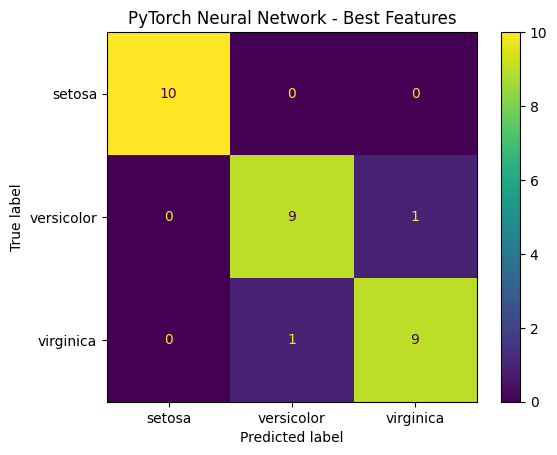

In [45]:
print(
    classification_report(
        y_test,
        y_pred_nn_best,
        target_names=target_names
    )
)

cm = confusion_matrix(
    y_test,
    y_pred_nn_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot()
plt.title("PyTorch Neural Network - Best Features")
plt.show()

## 18. So sánh kết quả

Ta so sánh:

- Logistic Regression dùng 4 đặc trưng
- Logistic Regression dùng các đặc trưng tốt nhất
- Logistic Regression chỉ dùng 2 Petal features
- PyTorch Neural Network dùng 4 đặc trưng
- PyTorch Neural Network dùng các đặc trưng tốt nhất

In [46]:
summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "PyTorch Neural Network",
        "PyTorch Neural Network"
    ],

    "Features": [
        "All 4",
        "Best by CV",
        "Petal Length + Petal Width",
        "All 4",
        "Best by CV"
    ],

    "N_features": [
        4,
        len(best_feature_indices),
        2,
        4,
        len(best_feature_indices)
    ],

    "Test Accuracy": [
        acc_lr_all,
        acc_lr_best,
        acc_lr_petal,
        acc_nn_all,
        acc_nn_best
    ]
})

summary.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Features,N_features,Test Accuracy
0,Logistic Regression,All 4,4,0.933333
1,Logistic Regression,Best by CV,1,0.933333
2,Logistic Regression,Petal Length + Petal Width,2,0.933333
3,PyTorch Neural Network,All 4,4,0.933333
4,PyTorch Neural Network,Best by CV,1,0.933333


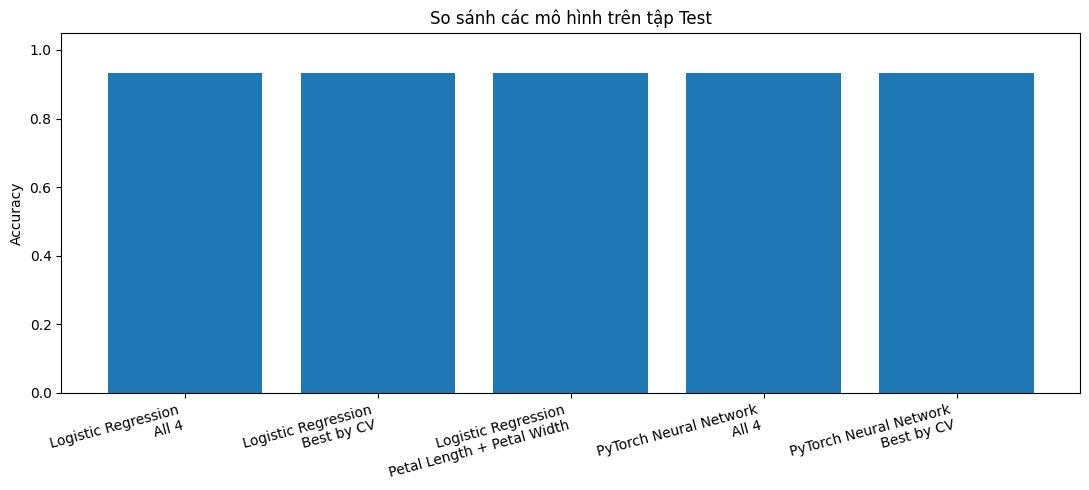

In [47]:
# Biểu đồ so sánh Accuracy
summary_plot = summary.copy()

summary_plot["Experiment"] = (
    summary_plot["Model"]
    + "\n"
    + summary_plot["Features"]
)

plt.figure(figsize=(11, 5))
plt.bar(
    summary_plot["Experiment"],
    summary_plot["Test Accuracy"]
)

plt.title("So sánh các mô hình trên tập Test")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Nhận xét kết quả

- **Đặc trưng tốt nhất:** ANOVA F-test và Mutual Information đều xếp `petal length` và `petal width` ở hai vị trí đầu (F-score ≈ 877 và 751; MI ≈ 0.99), vượt xa `sepal length` (F ≈ 98) và `sepal width` (F ≈ 33). Điều này khớp với hệ số tương quan với nhãn (≈ 0.95–0.96 so với 0.78 và −0.42) và với pairplot: hai biến petal tách rõ 3 loài.
- **Cross-Validation chọn 1 đặc trưng (`petal width`)** với CV accuracy ≈ 0.966, nhưng chênh lệch với tổ hợp 2 đặc trưng petal (≈ 0.957) chỉ khoảng 0.01, nhỏ hơn nhiều so với độ lệch chuẩn giữa các fold (≈ 0.017). **Nói cách khác, các tổ hợp đứng đầu thực chất không khác nhau có ý nghĩa thống kê**; việc chọn ít đặc trưng nhất là theo nguyên tắc đơn giản (Occam), không phải vì nó vượt trội.
- **Kết quả trên test:** cả 5 thí nghiệm đều đạt Accuracy ≈ 0.933. Tập test chỉ có 30 mẫu nên **mỗi mẫu sai làm giảm 3.3%**, vì vậy không thể kết luận mô hình nào tốt hơn. Lỗi tập trung ở cặp `versicolor` – `virginica` (khớp với mô tả của bộ dữ liệu: hai loài này không tách tuyến tính hoàn toàn); `setosa` luôn được phân loại đúng.
- **Chuẩn hóa:** với Iris (4 đặc trưng cùng đơn vị cm) chuẩn hóa gần như không cải thiện; chênh lệch giữa Min-Max, Standard và không chuẩn hóa là nhỏ và không nhất quán giữa các mô hình. Chuẩn hóa vẫn nên giữ khi dùng Neural Network để việc tối ưu ổn định.
- **Xóa trùng lặp:** 3 dòng trùng đã được loại (150 → 147 mẫu) trước khi chia train/test.
- **Hạn chế:** dữ liệu nhỏ, kết quả phụ thuộc cách chia train/test. Nếu cần so sánh chắc chắn hơn nên dùng Repeated Stratified K-Fold trên toàn bộ dữ liệu.


## 19. Quan sát các mẫu dự đoán sai của PyTorch

Phân tích lỗi giúp trả lời:

- Lớp nào dễ nhầm với nhau?
- Những mẫu sai nằm gần ranh giới giữa hai lớp hay không?
- Hai lớp `versicolor` và `virginica` có khó phân biệt hơn `setosa` không?

In [48]:
wrong_idx = np.where(
    y_pred_nn_all != y_test
)[0]

print(
    f"Số mẫu dự đoán sai: "
    f"{len(wrong_idx)} / {len(y_test)}"
)

if len(wrong_idx) > 0:

    error_df = pd.DataFrame(
        X_test[wrong_idx],
        columns=feature_names
    )

    error_df["Actual"] = target_names[
        y_test[wrong_idx]
    ]

    error_df["Predicted"] = target_names[
        y_pred_nn_all[wrong_idx]
    ]

    display(error_df)

else:
    print("Mô hình không dự đoán sai mẫu nào trong lần chạy này.")

Số mẫu dự đoán sai: 2 / 30


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Actual,Predicted
0,6.7,3.0,5.0,1.7,versicolor,virginica
1,6.0,3.0,4.8,1.8,virginica,versicolor


## 20. Kết luận

Qua bài thực hành, ta đã thực hiện một pipeline đầy đủ:

```text
IRIS DATASET
      │
      ▼
Data Inspection
      │
      ▼
EDA / Visualization
      │
      ▼
Train-Test Split
      │
      ▼
Feature Analysis
 ┌────┼───────────────┐
 │    │               │
ANOVA Mutual Info  Cross-Validation
 └────┼───────────────┘
      ▼
Best Features
      │
 ┌────┴───────────┐
 ▼                ▼
Scikit-Learn    PyTorch
 ▼                ▼
Evaluation      Evaluation
 └───────┬────────┘
         ▼
      Compare
```

### Các ý chính

1. Không nên đưa dữ liệu trực tiếp vào mô hình mà bỏ qua bước khảo sát.
2. `petal length` và `petal width` thường là những đặc trưng rất mạnh của Iris.
3. Tuy nhiên, việc chọn đặc trưng nên được xác nhận bằng phương pháp định lượng.
4. Không được dùng tập test để chọn feature hoặc fit scaler.
5. Ít đặc trưng hơn không đồng nghĩa với mô hình kém hơn.
6. Với bộ dữ liệu nhỏ như Iris, mô hình ML truyền thống có thể đã đạt kết quả rất tốt.
7. Neural Network vẫn hữu ích để minh họa quy trình Deep Learning/PyTorch.
8. Accuracy không phải chỉ số duy nhất; cần quan sát thêm Precision, Recall, F1 và Confusion Matrix.

## 21. Câu hỏi thảo luận và bài tập mở rộng

### Câu hỏi thảo luận

1. Đặc trưng nào có F-score lớn nhất?
2. Đặc trưng nào có Mutual Information lớn nhất?
3. Kết quả ANOVA và Mutual Information có giống nhau không?
4. Tổ hợp đặc trưng nào có Cross-Validation Accuracy cao nhất?
5. Chỉ dùng `petal length` và `petal width` có đủ tốt không?
6. Logistic Regression và PyTorch, mô hình nào tốt hơn trong lần chạy này?
7. Tại sao `StandardScaler` chỉ được fit trên tập train?
8. Điều gì xảy ra nếu bỏ bước chuẩn hóa?
9. Tại sao không cần Softmax ở tầng cuối khi dùng `CrossEntropyLoss`?
10. Với 150 mẫu, có cần một Neural Network rất sâu không?

### Bài tập mở rộng

- Thử thay Logistic Regression bằng Random Forest.
- Thử các giá trị `k` khác nhau cho KNN.
- Thử kernel `linear`, `rbf`, `poly` cho SVM.
- Thay số neuron của PyTorch: `4 → 8 → 3`, `4 → 32 → 16 → 3`.
- Thử learning rate: `0.1`, `0.01`, `0.001`.
- Thực hiện 10-fold Cross-Validation.
- So sánh kết quả khi có và không có StandardScaler.
- Thử PCA giảm từ 4 chiều xuống 2 chiều và trực quan hóa.

## Kết thúc